<a href="https://colab.research.google.com/github/vitalinamysiv/restaurant-visitor-forecasting/blob/main/notebooks/02_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Моделирование

## Цель

Построить модель для прогнозирования количества посетителей ресторана на следующие 7 дней.

## Этапы работы

1. Генерация признаков:
   - календарные признаки;
   - лаговые признаки;
   - скользящие статистики.

2. Разделение данных:
   - обучение на исторических данных;
   - проверка качества на будущем периоде.

3. Построение бейзлайн-модели.

4. Обучение и сравнение ML-моделей.

## Целевая переменная

`guests` — количество посетителей ресторана за день.

## 0. Настройка окружения

Импортируем библиотеки, фиксируем `random_state` для воспроизводимости.  
Устанавливаем CatBoost, если он ещё не установлен в окружении.

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Фиксируем seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Установка CatBoost
!pip install -q catboost

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00


## 1. Загрузка данных

Загружаем подготовленный датасет и применяем `make_features` из `src/features.py`.

> **Важно:** эта же функция используется и при инференсе в `predict.py`, чтобы не было расхождения между train и predict (train/inference skew).

In [7]:
from src.features import make_features

df = pd.read_csv(
    "data/processed/restaurant_daily.csv",
    parse_dates=["date"],
)

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (844338, 7)


,restaurant_id,date,revenue,guests,is_state_holiday,is_school_holiday,is_promo
0,1,2013-01-02,5530.0,668.0,0,1,0
1,1,2013-01-03,4327.0,578.0,0,1,0
2,1,2013-01-04,4486.0,619.0,0,1,0
3,1,2013-01-05,4997.0,635.0,0,1,0
4,1,2013-01-07,7176.0,785.0,0,1,1


In [8]:
df_features = make_features(df)

print("Размер с признаками:", df_features.shape)
df_features.head()

Размер с признаками: (844338, 19)


,restaurant_id,date,revenue,guests,is_state_holiday,is_school_holiday,is_promo,day_of_week,month,day_of_month,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28
0,1,2013-01-02,5530.0,668.0,0,1,0,2,1,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327.0,578.0,0,1,0,3,1,3,0,668.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,2013-01-04,4486.0,619.0,0,1,0,4,1,4,0,578.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,2013-01-05,4997.0,635.0,0,1,0,5,1,5,1,619.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,2013-01-07,7176.0,785.0,0,1,1,0,1,7,0,635.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Удаляем строки, где не хватает истории для расчёта лагов
# (первые 28 дней каждого ресторана)
df_features = df_features.dropna().reset_index(drop=True)

print("Размер после dropna:", df_features.shape)

Размер после dropna: (813118, 19)


## 2. Разбиение по времени

Используем `time_split` из `src/validation.py`.  
Разбиение строго по времени — **без перемешивания**, чтобы эмулировать реальный прогноз на будущее.

- **Train:** до 2015-06-19
- **Valid:** 2015-06-20 — 2015-07-31 (6 недель)

In [10]:
from src.validation import time_split

train, valid = time_split(df_features, valid_weeks=6)

print("Train:", train["date"].min().date(), "—", train["date"].max().date())
print("Valid:", valid["date"].min().date(), "—", valid["date"].max().date())
print("Размер train:", train.shape)
print("Размер valid:", valid.shape)

Train: 2013-01-29 — 2015-06-19
Valid: 2015-06-20 — 2015-07-31
Размер train: (772836, 19)
Размер valid: (40282, 19)


## 3. Бейзлайн: сезонный наивный прогноз

В качестве бейзлайна используем **прогноз = значение того же дня недели неделю назад** (`lag_7`).

Такой подход учитывает недельную сезонность и служит точкой сравнения для ML-моделей.  
**Без бейзлайна метрика модели ничего не значит.**

In [11]:
baseline_pred = valid["lag_7"]

mae_baseline = mean_absolute_error(valid["guests"], baseline_pred)
mape_baseline = mean_absolute_percentage_error(valid["guests"], baseline_pred)

print(f"Baseline (lag_7) MAE:  {mae_baseline:.2f}")
print(f"Baseline (lag_7) MAPE: {mape_baseline:.2%}")

Baseline (lag_7) MAE:  163.40
Baseline (lag_7) MAPE: 24.91%


## 4. Набор признаков для модели

Используем набор признаков, согласованный с `predict.py`:

- **календарные:** `day_of_week`, `month`, `day_of_month`, `is_weekend`;
- **лаги:** `lag_1`, `lag_7`, `lag_14`;
- **скользящие средние:** `rolling_mean_7`, `rolling_mean_28`;
- **идентификатор точки:** `restaurant_id`;
- **выручка:** `revenue`.

`revenue` на инференсе неизвестна заранее — в `predict.py` подставляется последнее доступное значение.

In [12]:
features = [
    "restaurant_id",
    "revenue",
    "day_of_week",
    "month",
    "day_of_month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28",
]

X_train = train[features]
y_train = train["guests"]

X_valid = valid[features]
y_valid = valid["guests"]

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

X_train: (772836, 11)
X_valid: (40282, 11)


## 5. Линейная модель: Ridge Regression

Ridge — простая линейная модель, которая служит ориентиром для сравнения с нелинейными алгоритмами.  
Она использует те же признаки, что и CatBoost, — это позволяет честно сравнить два подхода.

In [17]:
from src.model import train_ridge

ridge_model = train_ridge(X_train, y_train)
ridge_pred = ridge_model.predict(X_valid)

ridge_mae = mean_absolute_error(y_valid, ridge_pred)
ridge_mape = mean_absolute_percentage_error(y_valid, ridge_pred)

print(f"Ridge MAE:  {ridge_mae:.2f}")
print(f"Ridge MAPE: {ridge_mape:.2%}")

Ridge MAE:  69.67
Ridge MAPE: 10.31%


## 6. Градиентный бустинг: CatBoost

CatBoost — основная модель проекта.  
Он хорошо работает с табличными данными, устойчив к выбросам и улавливает нелинейные зависимости.

Обучение реализовано в `src/model.py` (`train_model`), чтобы код был переиспользуемым.

In [16]:
from src.model import train_catboost

catboost_model = train_catboost(X_train, y_train)

catboost_pred = catboost_model.predict(X_valid)

catboost_mae = mean_absolute_error(y_valid, catboost_pred)
catboost_mape = mean_absolute_percentage_error(y_valid, catboost_pred)

print(f"CatBoost MAE:  {catboost_mae:.2f}")
print(f"CatBoost MAPE: {catboost_mape:.2%}")

0:	learn: 248.7405911	total: 320ms	remaining: 2m 39s
100:	learn: 63.6690491	total: 18.7s	remaining: 1m 14s
200:	learn: 58.0301661	total: 34.3s	remaining: 51s
300:	learn: 55.2504278	total: 50s	remaining: 33.1s
400:	learn: 53.3267198	total: 1m 8s	remaining: 16.8s
499:	learn: 51.8722777	total: 1m 27s	remaining: 0us
CatBoost MAE:  50.06
CatBoost MAPE: 7.17%


## 7. Сравнение моделей

Все три подхода были обучены на одних и тех же данных и проверены на одном и том же отложенном периоде.

| Модель             | MAE    | MAPE   |
|--------------------|--------|--------|
| Baseline (lag_7)   | 163.40 | 24.91% |
| Ridge Regression   | 69.67  | 10.31% |
| **CatBoost**       | **50.06** | **7.17%** |

**Улучшение относительно baseline:**

- MAE: **163.40 → 50.06** (−69%);
- MAPE: **24.91% → 7.17%** (−71%).

CatBoost показал лучшее качество на отложенном временном периоде.  
Использование лагов, календарных признаков и скользящих средних позволило значительно улучшить прогноз относительно наивного бейзлайна.

## 8. Важность признаков

CatBoost умеет оценивать вклад каждого признака в прогноз.  
Смотрим, какие признаки оказались наиболее важными — это помогает понять, на чём именно «держится» модель.

In [19]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": catboost_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance

,feature,importance
10,rolling_mean_28,37.548627
1,revenue,26.779775
6,lag_1,14.673057
9,rolling_mean_7,7.419092
2,day_of_week,5.226247
0,restaurant_id,1.991892
3,month,1.571932
5,is_weekend,1.532832
4,day_of_month,1.353181
8,lag_14,1.177674


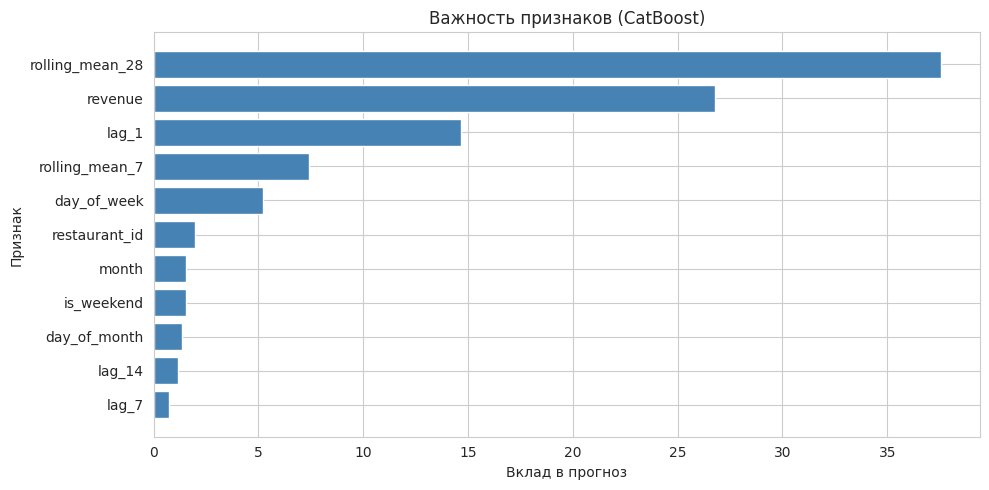

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    importance["feature"],
    importance["importance"],
    color="steelblue",
)

ax.invert_yaxis()  # самый важный признак — сверху

ax.set_title("Важность признаков (CatBoost)")
ax.set_xlabel("Вклад в прогноз")
ax.set_ylabel("Признак")

plt.tight_layout()
plt.show()

Вывод:

Наиболее важные признаки для модели:

1. `rolling_mean_28` — долгосрочный уровень спроса (средний поток за 4 недели).
2. `revenue` — масштаб активности точки (косвенно отражает поток).
3. `lag_1` — краткосрочная динамика (вчерашний поток).
4. `rolling_mean_7` — недельный тренд спроса.
5. `day_of_week` — недельная сезонность.

Модель опирается преимущественно на **исторические показатели спроса** и **календарные признаки**. Это ожидаемо для задачи прогнозирования временных рядов и говорит о том, что модель выучила осмысленные зависимости, а не шум.

## 9. Сохранение модели

Сохраняем обученную модель CatBoost в `models/catboost_model.pkl`.  
Эта же модель будет загружаться в `predict.py` для получения прогноза без переобучения.

In [21]:
from src.model import save_model

save_model(catboost_model)

print("Модель сохранена: models/catboost_model.pkl")

Модель сохранена: models/catboost_model.pkl


## 10. Выводы

По результатам моделирования можно сформулировать следующие выводы:

### Качество моделей

1. **Baseline (lag_7)** — наивный сезонный прогноз. MAE ≈ 163, MAPE ≈ 25%. Это точка отсчёта: без неё метрики ML-моделей не имеют смысла.

2. **Ridge Regression** — линейная модель на календарных признаках и лагах. MAE ≈ 70, MAPE ≈ 10%. Существенное улучшение относительно baseline.

3. **CatBoost** — градиентный бустинг, лучшая модель проекта. MAE ≈ 50, MAPE ≈ 7%. Снижение ошибки почти в 3.3 раза по сравнению с baseline.

### Что дало прирост качества

- **Лаги** (`lag_1`, `lag_7`, `lag_14`) уловили краткосрочную динамику.
- **Скользящие средние** (`rolling_mean_7`, `rolling_mean_28`) сгладили шум.
- **Календарные признаки** (`day_of_week`, `month`) учли недельную и годовую сезонность.

### Важность признаков

Топ-5 признаков: `rolling_mean_28`, `revenue`, `lag_1`, `rolling_mean_7`, `day_of_week`.  
Модель опирается на исторические показатели спроса — это ожидаемо для временных рядов.

### Что дальше

Обученная модель сохранена в `models/catboost_model.pkl` и используется в `predict.py` для прогноза на 7 дней вперёд.